In [ ]:
import yfinance as yf 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib as m 
import seaborn as sns 

In [1]:
import scipy

In [2]:
import yfinance as yf 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib as m 
import seaborn as sns 

In [3]:
import warnings

In [4]:
warnings.filterwarnings("ignore")

In [5]:
plt.style.use('fivethirtyeight')

In [6]:
m.rcParams['axes.labelsize'] = 14
m.rcParams['xtick.labelsize'] = 12
m.rcParams['ytick.labelsize'] = 12
m.rcParams['text.color'] = 'k'

from matplotlib.pylab import  rcParams

rcParams['figure.figsize'] = 20, 10


pd.options.display.float_format = '{:.2f}' .format

In [7]:
Cotacoes = yf.Ticker("BTC-USD")

In [8]:
dados = Cotacoes.history(period="1y")

In [9]:
dados.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2024-11-21 00:00:00+00:00,94334.64,99014.22,94132.60,98504.73,106024505582,0.00,0.00
2024-11-22 00:00:00+00:00,98496.43,99655.50,97222.66,98997.66,78473580551,0.00,0.00
2024-11-23 00:00:00+00:00,99006.74,99014.68,97232.89,97777.28,44414644677,0.00,0.00
2024-11-24 00:00:00+00:00,97778.09,98647.18,95788.08,98013.82,51712020623,0.00,0.00
2024-11-25 00:00:00+00:00,98033.45,98935.03,92642.91,93102.30,80909462490,0.00,0.00


In [10]:
dados.drop('Dividends', axis=1, inplace=True)
dados.drop('Stock Splits', axis=1, inplace=True)
dados.columns = ['Abertura','Maximo','Minimo', 'Fechamento','Volume']
dados.head ()

,Abertura,Maximo,Minimo,Fechamento,Volume
Date,,,,,
2024-11-21 00:00:00+00:00,94334.64,99014.22,94132.60,98504.73,106024505582
2024-11-22 00:00:00+00:00,98496.43,99655.50,97222.66,98997.66,78473580551
2024-11-23 00:00:00+00:00,99006.74,99014.68,97232.89,97777.28,44414644677
2024-11-24 00:00:00+00:00,97778.09,98647.18,95788.08,98013.82,51712020623
2024-11-25 00:00:00+00:00,98033.45,98935.03,92642.91,93102.30,80909462490


In [11]:
print('Menor Data: ', dados.index.min())
print('Maior Data ', dados.index.max())

Menor Data:  2024-11-21 00:00:00+00:00
Maior Data  2025-11-21 00:00:00+00:00


In [12]:
display(dados.loc[dados.index.max()])

Abertura            86523.95
Maximo              87303.64
Minimo              80760.66
Fechamento          85235.38
Volume       128785342464.00
Name: 2025-11-21 00:00:00+00:00, dtype: float64

In [13]:
dados.columns = ['Abertura','Maximo','Minimo', 'Fechamento','Volume']
dados.head ()

,Abertura,Maximo,Minimo,Fechamento,Volume
Date,,,,,
2024-11-21 00:00:00+00:00,94334.64,99014.22,94132.60,98504.73,106024505582
2024-11-22 00:00:00+00:00,98496.43,99655.50,97222.66,98997.66,78473580551
2024-11-23 00:00:00+00:00,99006.74,99014.68,97232.89,97777.28,44414644677
2024-11-24 00:00:00+00:00,97778.09,98647.18,95788.08,98013.82,51712020623
2024-11-25 00:00:00+00:00,98033.45,98935.03,92642.91,93102.30,80909462490


In [14]:
display(dados.loc[dados.index.max()])

Abertura            86523.95
Maximo              87303.64
Minimo              80760.66
Fechamento          85235.38
Volume       128785342464.00
Name: 2025-11-21 00:00:00+00:00, dtype: float64

In [15]:
retorno_diario = dados["Fechamento"].pct_change().dropna()
retorno_diario.head

<bound method NDFrame.head of Date
2024-11-22 00:00:00+00:00    0.01
2024-11-23 00:00:00+00:00   -0.01
2024-11-24 00:00:00+00:00    0.00
2024-11-25 00:00:00+00:00   -0.05
2024-11-26 00:00:00+00:00   -0.01
                             ... 
2025-11-17 00:00:00+00:00   -0.02
2025-11-18 00:00:00+00:00    0.01
2025-11-19 00:00:00+00:00   -0.02
2025-11-20 00:00:00+00:00   -0.05
2025-11-21 00:00:00+00:00   -0.02
Name: Fechamento, Length: 365, dtype: float64>

In [16]:
dados = pd.merge(dados, retorno_diario, how = 'inner' , on = 'Date')
dados.columns = ['Abertura' , 'Maximo' , 'Minimo' , 'Fechamento' , 'Volume' , 'Variacao_Diaria']
dados.head ()

,Abertura,Maximo,Minimo,Fechamento,Volume,Variacao_Diaria
Date,,,,,,
2024-11-22 00:00:00+00:00,98496.43,99655.50,97222.66,98997.66,78473580551,0.01
2024-11-23 00:00:00+00:00,99006.74,99014.68,97232.89,97777.28,44414644677,-0.01
2024-11-24 00:00:00+00:00,97778.09,98647.18,95788.08,98013.82,51712020623,0.00
2024-11-25 00:00:00+00:00,98033.45,98935.03,92642.91,93102.30,80909462490,-0.05
2024-11-26 00:00:00+00:00,93087.28,94991.75,90770.81,91985.32,91656519855,-0.01


In [17]:
dados.dtypes

Abertura           float64
Maximo             float64
Minimo             float64
Fechamento         float64
Volume               int64
Variacao_Diaria    float64
dtype: object

In [18]:
dados.shape

(365, 6)

In [19]:
dados.describe

<bound method NDFrame.describe of                            Abertura   Maximo   Minimo  Fechamento  \
Date                                                                
2024-11-22 00:00:00+00:00  98496.43 99655.50 97222.66    98997.66   
2024-11-23 00:00:00+00:00  99006.74 99014.68 97232.89    97777.28   
2024-11-24 00:00:00+00:00  97778.09 98647.18 95788.08    98013.82   
2024-11-25 00:00:00+00:00  98033.45 98935.03 92642.91    93102.30   
2024-11-26 00:00:00+00:00  93087.28 94991.75 90770.81    91985.32   
...                             ...      ...      ...         ...   
2025-11-17 00:00:00+00:00  94180.88 95928.37 91214.76    92093.88   
2025-11-18 00:00:00+00:00  92094.53 93745.08 89300.46    92948.88   
2025-11-19 00:00:00+00:00  92946.16 92946.16 88526.83    91465.99   
2025-11-20 00:00:00+00:00  91459.35 93025.07 86040.80    86631.90   
2025-11-21 00:00:00+00:00  86523.95 87303.64 80760.66    85235.38   

                                 Volume  Variacao_Diaria  
Date     

In [20]:
dados.describe()

,Abertura,Maximo,Minimo,Fechamento,Volume,Variacao_Diaria
count,365.00,365.00,365.00,365.00,365.00,365.00
mean,102645.15,104237.60,100838.37,102609.08,54736567925.78,-0.00
std,11003.17,10880.76,11227.77,11038.01,25028488900.90,0.02
min,76273.56,80823.89,74436.68,76271.95,9863214091.00,-0.09
25%,95556.87,96855.59,93712.51,95539.55,37147280860.00,-0.01
50%,103735.66,105418.37,101515.09,103744.64,51486264208.00,-0.00
75%,111032.62,112600.23,109372.95,111033.92,69550440846.00,0.01
max,124752.14,126198.07,123196.05,124752.53,181746419401.00,0.10


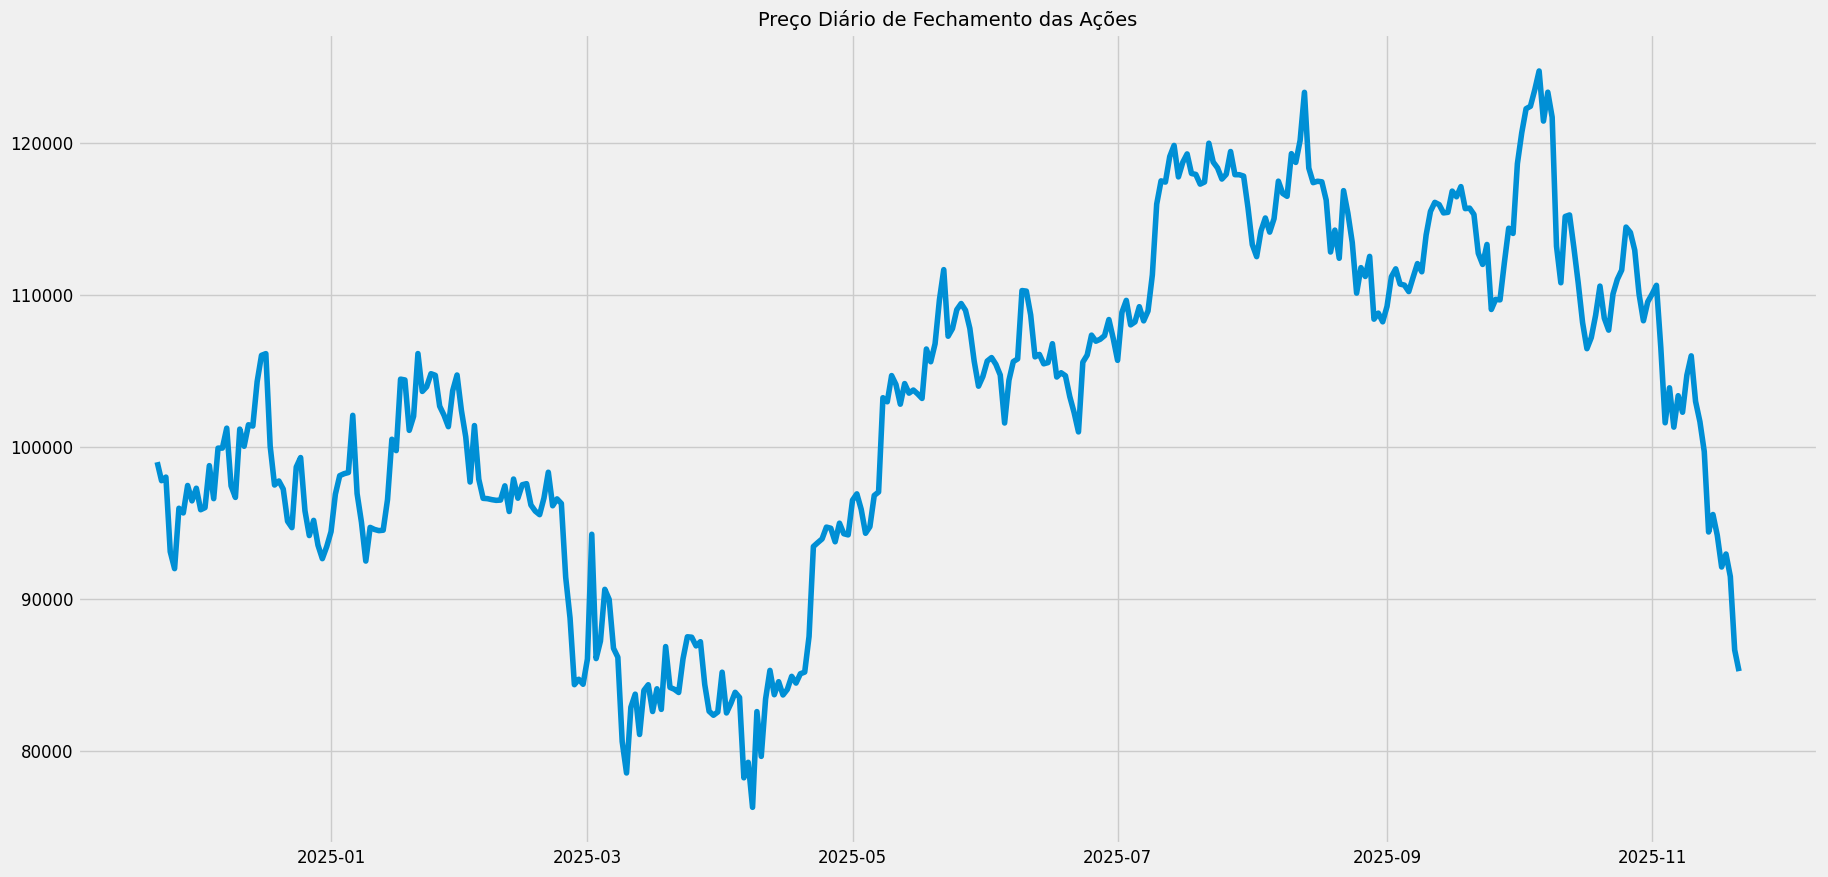

In [21]:
plt.plot(dados["Fechamento"])
plt.title("Preço Diário de Fechamento das Ações", size = 14)
plt.show()

In [22]:
retorno_diario_acumulado = (1+ retorno_diario).cumprod() - 1
retorno_diario_acumulado.max()

np.float64(0.26646238818647916)

In [23]:
media_retorno_diario = np.mean(retorno_diario)

In [24]:
desvio_retorno_diario = np.std(retorno_diario)

In [25]:
print("Média do Retorno de Fechamento: ", media_retorno_diario)
print("Desvio Padrão do Retorno de Fechamento: ", desvio_retorno_diario)

Média do Retorno de Fechamento:  -0.00014618029441866936
Desvio Padrão do Retorno de Fechamento:  0.02236785332258439


In [26]:
print("Retorno Médio Anualizado de Fechamento: ", (1 + media_retorno_diario) ** 364-1)
print("Desvio Padrão Anualizado de Fechamento: ", desvio_retorno_diario*np.sqrt(364))

Retorno Médio Anualizado de Fechamento:  -0.05182246082151243
Desvio Padrão Anualizado de Fechamento:  0.42675144271915055


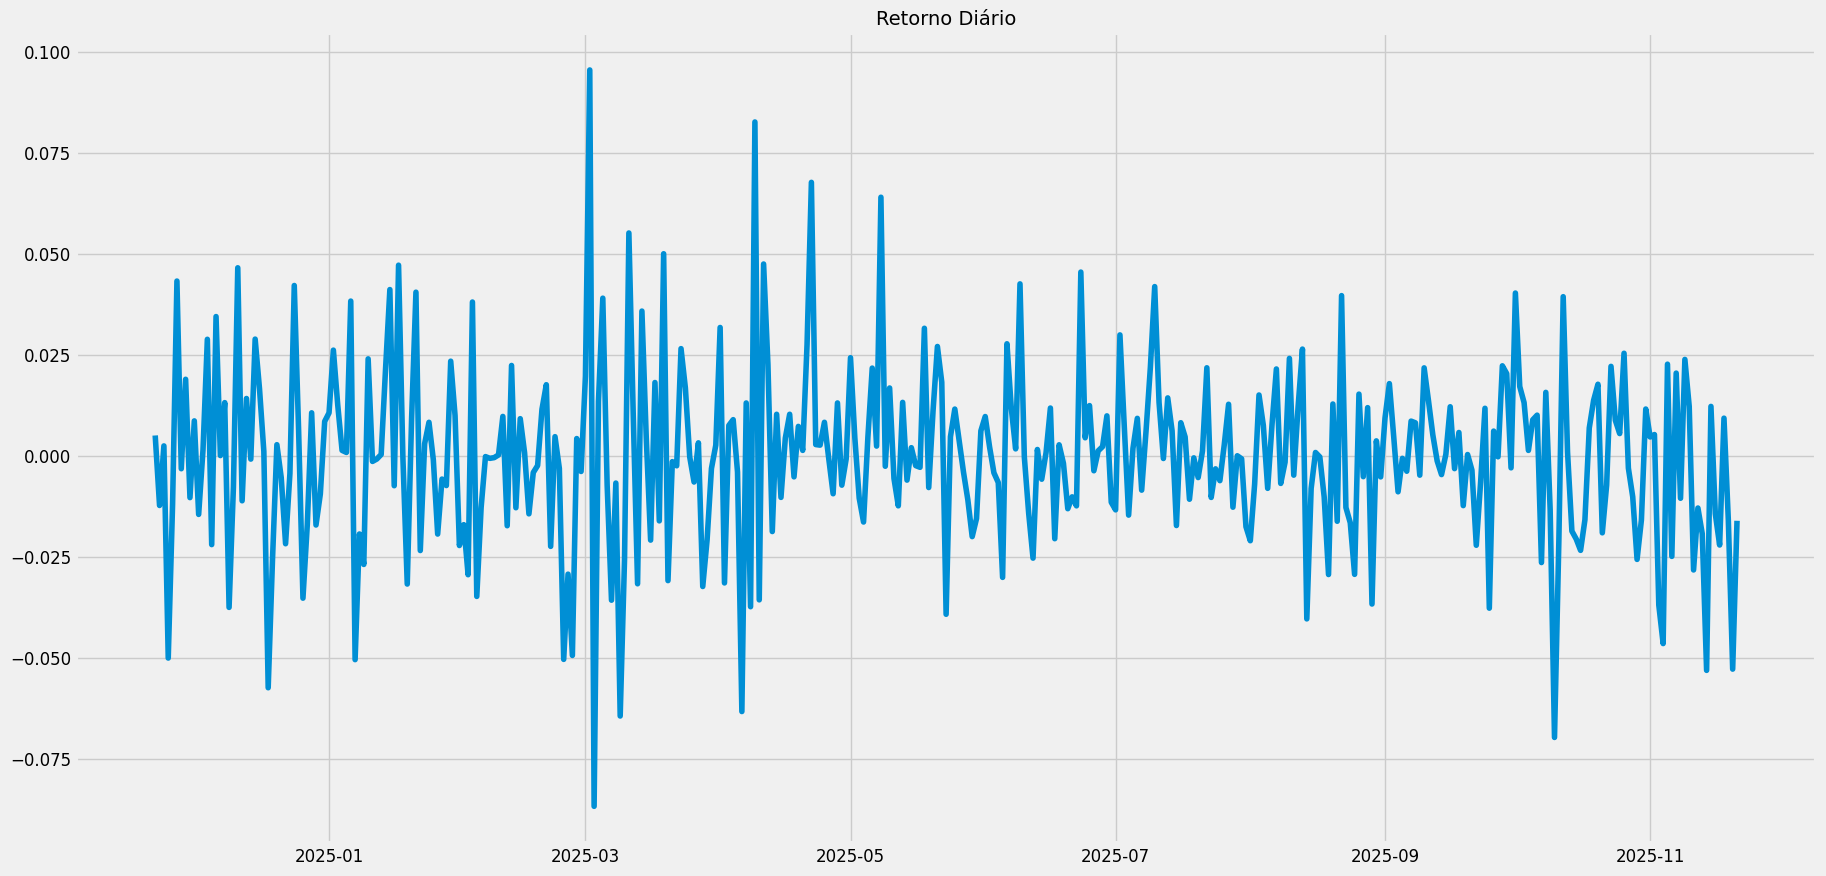

In [27]:
plt.plot(retorno_diario)
plt.title("Retorno Diário", size = 14)
plt.show ()

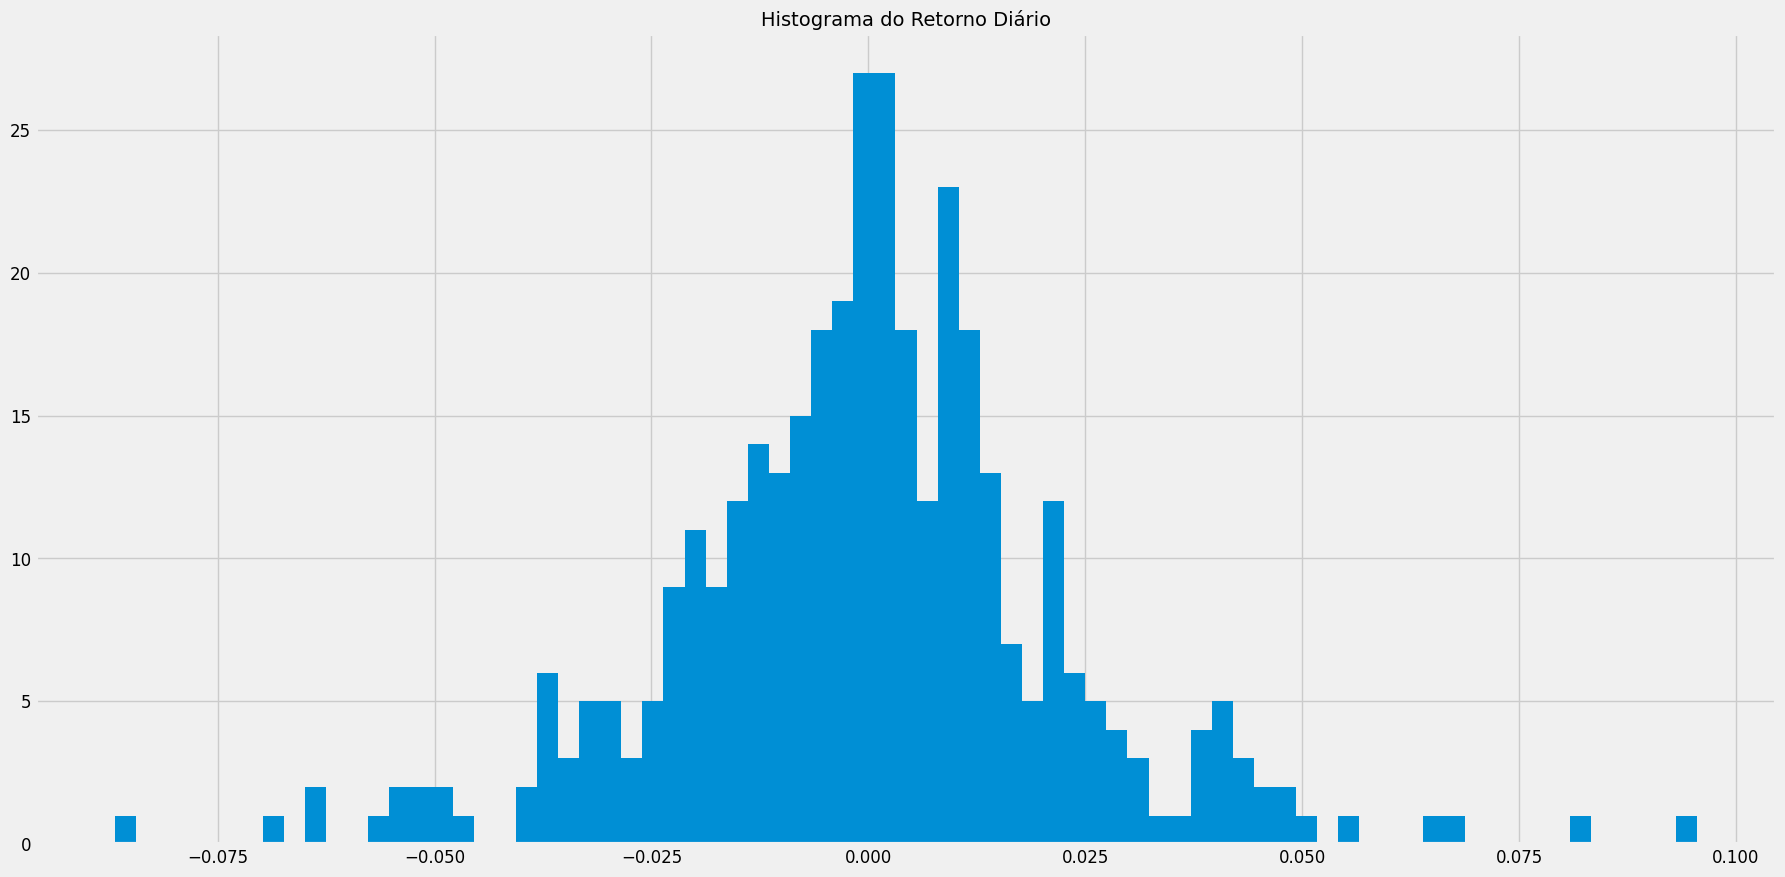

In [28]:
plt.hist(retorno_diario, bins = 75)
plt.title("Histograma do Retorno Diário", size = 14)
plt.show()

In [29]:
log_retorno_diario = (np.log(dados["Fechamento"]) - np.log(dados["Fechamento"]).shift(-1)).dropna()

In [30]:
log_media_retorno_diario = np.mean(log_retorno_diario)
log_desvio_retorno_diario = np.std(log_retorno_diario)

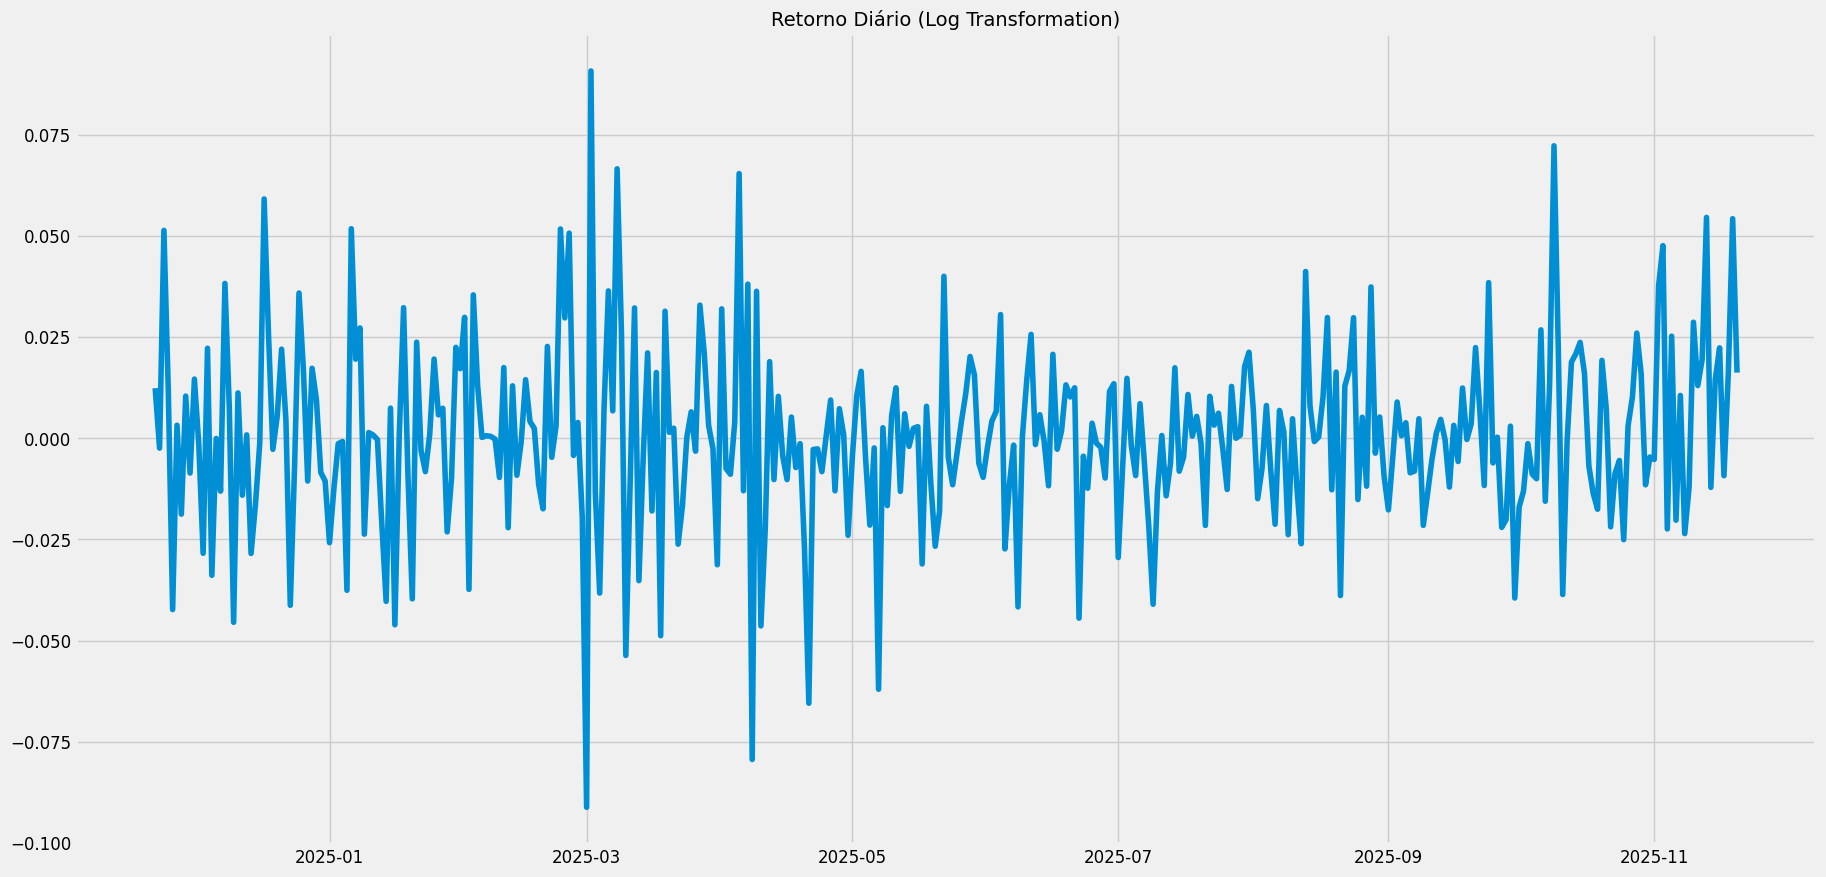

In [31]:
plt.plot(log_retorno_diario)
plt.title("Retorno Diário (Log Transformation)", size = 14)
plt.show()

(array([ 1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  1.,
         0.,  0.,  1.,  0.,  1.,  3.,  1.,  5.,  5.,  2.,  2.,  2.,  3.,
         6.,  5., 12.,  4.,  9.,  6., 24., 18., 14., 19., 19., 34., 17.,
        20., 17., 12., 14.,  8., 15.,  7., 12.,  3.,  6.,  5.,  5.,  1.,
         5.,  4.,  2.,  0.,  0.,  1.,  4.,  1.,  1.,  1.,  0.,  0.,  1.,
         1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([-0.09121501, -0.08878785, -0.08636068, -0.08393351, -0.08150634,
        -0.07907917, -0.076652  , -0.07422483, -0.07179766, -0.06937049,
        -0.06694332, -0.06451615, -0.06208898, -0.05966181, -0.05723464,
        -0.05480747, -0.0523803 , -0.04995313, -0.04752596, -0.04509879,
        -0.04267162, -0.04024445, -0.03781728, -0.03539011, -0.03296294,
        -0.03053578, -0.02810861, -0.02568144, -0.02325427, -0.0208271 ,
        -0.01839993, -0.01597276, -0.01354559, -0.01111842, -0.00869125,
        -0.00626408, -0.00383691, -0.00140974,  0.00101743,  0.0

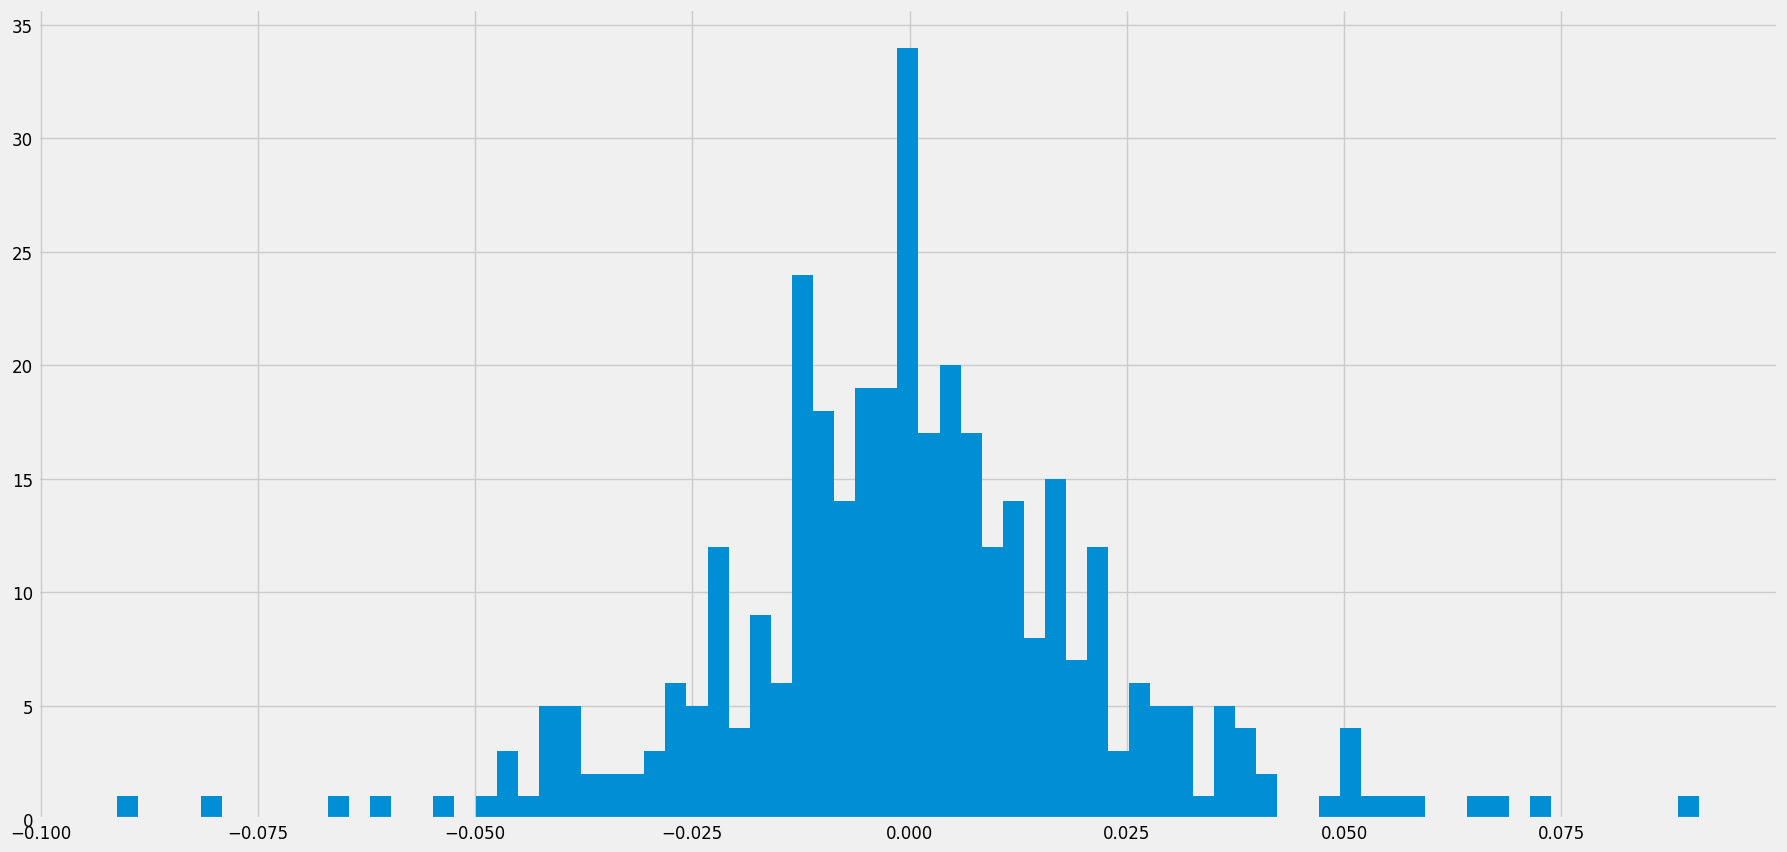

In [32]:
plt.hist(log_retorno_diario, bins = 75)

In [39]:
var_level = 95
var = np.percentile(log_retorno_diario, 100 - var_level)
print("Certeza que as perdas diárias não excederão o Var% em um determinado dia com base nos valores históricos.")
print("Var 95%", var)

Certeza que as perdas diárias não excederão o Var% em um determinado dia com base nos valores históricos.
Var 95% -0.03855625725026907


In [42]:
var * np.sqrt(5)

np.float64(-0.08621441216957078)

In [43]:
var_level = 95
var = np.percentile(log_retorno_diario, 100 - var_level)
cvar = log_retorno_diario[log_retorno_diario < var].mean()
print("Nos piores 2.5% dos casos as perdas foram , em média, superiores ao percentual histórico")
print("CVaR 95%", cvar)

Nos piores 2.5% dos casos as perdas foram , em média, superiores ao percentual histórico
CVaR 95% -0.04979843871967033


In [44]:
dias_posteriores = 180 
simulacoes = 2500
ultimo_preco =  85235.38
results = np.empty((simulacoes, dias_posteriores))

for s in range (simulacoes):

    random_returns = 1 + np.random.normal(loc= log_media_retorno_diario,
                                          scale= log_desvio_retorno_diario,
                                          size= dias_posteriores)
    
    result = ultimo_preco * (random_returns.cumprod())

    results[s,:] = result

In [45]:
index = pd.date_range("2025-11-22", periods = dias_posteriores, freq = "D")
resultados = pd.DataFrame(results.T, index = index)
media_resultados = resultados.apply("mean", axis = 1)

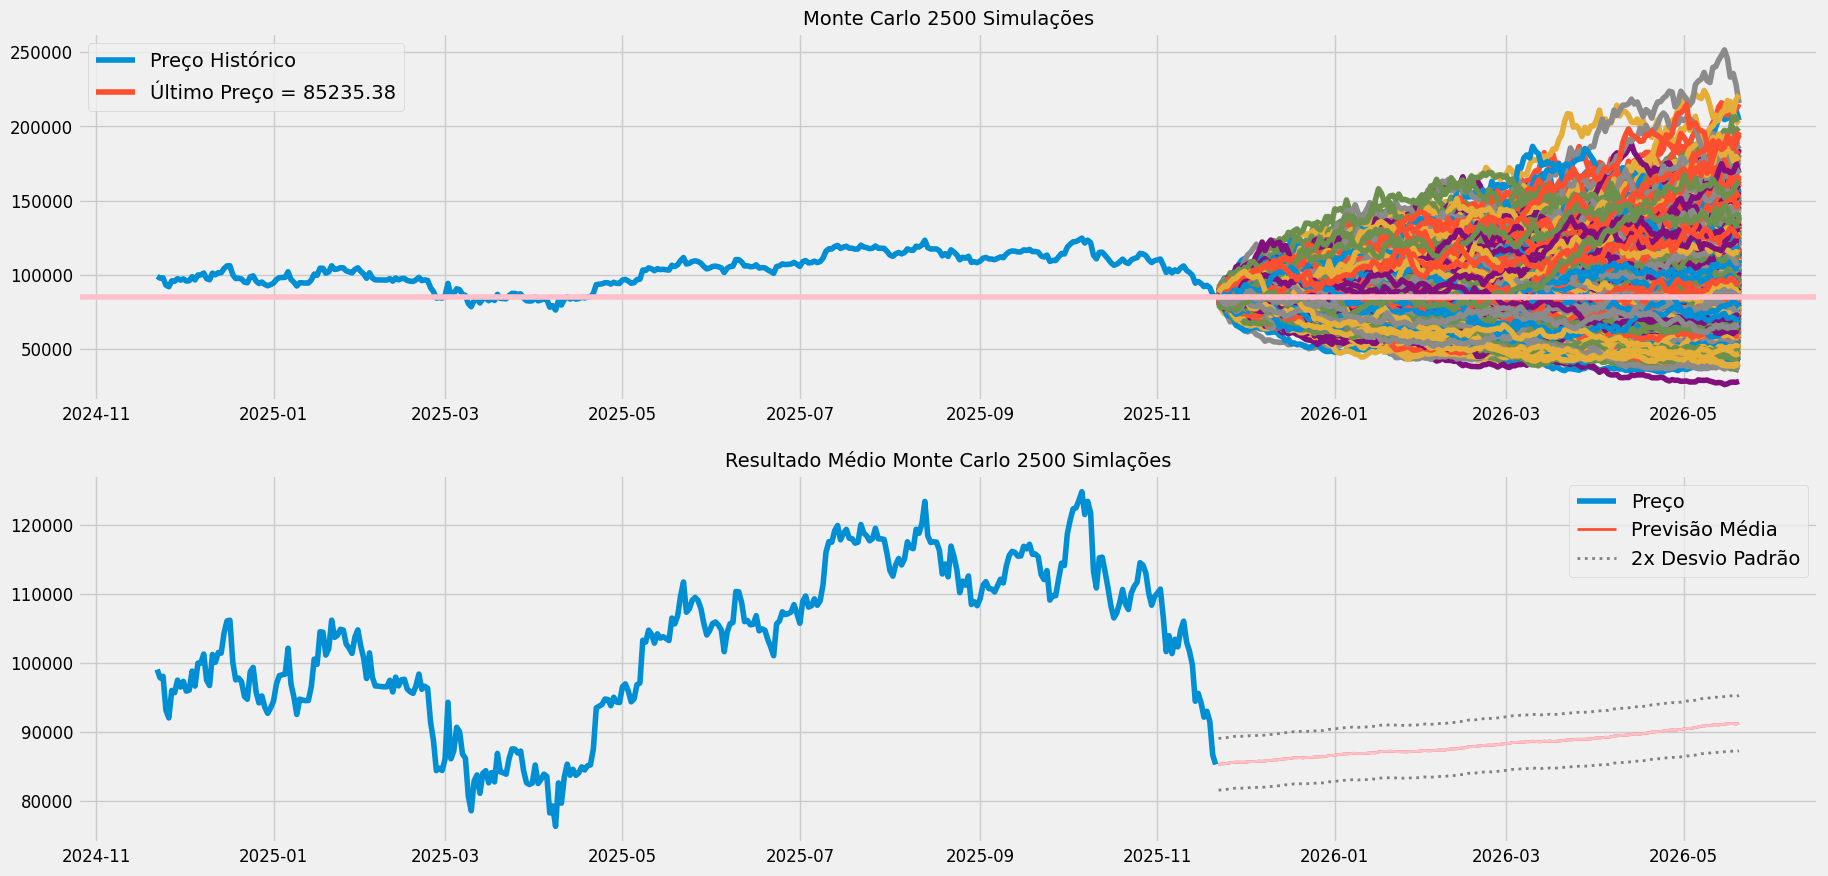

In [46]:
fig, ax = plt.subplots(nrows = 2, ncols = 1)

ax[0].plot(dados["Fechamento"][:"2026-05-19"])
ax[0].plot(resultados)
ax[0].axhline(85235.38, c = "pink")
ax[0].set_title(f"Monte Carlo {simulacoes} Simulações", size = 14)
ax[0].legend(["Preço Histórico", "Último Preço = 85235.38"])
ax[1].plot(dados["Fechamento"][:"2026-05-19"])
ax[1].plot(resultados.apply("mean", axis = 1), lw = 2)
ax[1].plot(media_resultados.apply((lambda x: x * (1+1.96*log_desvio_retorno_diario))),
           lw = 2, linestyle = "dotted", c = "gray")
ax[1].plot(media_resultados, lw = 2, c = "pink")
ax[1].plot(media_resultados.apply((lambda x: x * (1-1.96 * log_desvio_retorno_diario))),
           lw = 2, linestyle = "dotted", c = "gray")
ax[1].set_title(f"Resultado Médio Monte Carlo {simulacoes} Simlações", size = 14)
ax[1].legend(["Preço", "Previsão Média", "2x Desvio Padrão"])

plt.show()